In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install jsonlines
!pip install transformers

In [ ]:
import json 
import jsonlines
import requests
from pprint import pprint
from IPython.display import clear_output
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from sklearn.model_selection import train_test_split
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm, trange
import pandas as pd
import io
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
with jsonlines.open('/content/drive/MyDrive/The_final/common_sense/train_rand_split.jsonl', 'r') as fail:
    train = list(fail)

data_list = []
labels = []


for i in tqdm(range(len(train)//3)): 
                                   
    choices_list = []
    context_question_concept = []
    triple_list = []

    item = train[i]                                       
    question = item['question']['stem']

    concept = item['question']['question_concept']
    concept = concept.split()
    concept = '_'.join(concept)
    
    #создание контекста


    #делаем запрос
    path = 'http://api.conceptnet.io/c/en/' + str(concept)
    obj = requests.get(path).json()
    #описание концепта нужно будет искать в викисловаре
   






    choices = item['question']['choices']
    for el in choices:
        choices_list.append((el['label'], el['text']))

    #чтобы найти тройки, нужно искать каждый choice[1] в тройке, где первый узел - вопрос(второй - ответ, а ребро это их отношение(это идеал))
    for choice_elem in choices_list: 
        triple = None    
        new_triple = ''
        for edge_elem in obj['edges']:  
            if edge_elem['surfaceText']: 
                if choice_elem[1] in edge_elem['surfaceText']:
                  triple = edge_elem['surfaceText']
                  break

        if len(obj['edges']) > 3 and obj['edges'][1]['surfaceText'] != None:
            if triple == None:
              triple = obj['edges'][1]['surfaceText']  #если такой тройки не нашлось, взяли первую по релевантности             
              triple = triple.split()
              for slovo in triple:
                  new_triple += ' '
                  for bukva in slovo:                  
                    if bukva not in ('[', ']'):
                        new_triple += bukva
              triple_list.append(new_triple)

            else:
              triple = triple.split()
              for slovo in triple:
                  new_triple += ' '
                  for bukva in slovo:
                    if bukva not in ('[', ']'):
                        new_triple += bukva
              triple_list.append(new_triple)      
 
    #теперь нужно получить определение каждого ответа из викисловаря






          
  

    correctly_letter = item['answerKey']

    num = -1

    for choice in choices_list:
        num += 1
        if len(triple_list) > 0:
             data_list.append('Query:' + question + 'Answer:' + choice[1] + '. Triple:' + triple_list[num])
        else:
             data_list.append('Query:' + question + 'Answer:' + choice[1])


       
        if choice[0] != correctly_letter:
            labels.append('0')
        else:
            labels.append('1')

   


print('\n')
pprint(data_list[5:7])
print('Длина датасета: ', len(data_list))

100%|██████████| 3247/3247 [11:44<00:00,  4.61it/s]



['Query:Sammy wanted to go to where the people were.  Where might he '
 'go?Answer:race track. Triple: people can be stupid',
 'Query:Sammy wanted to go to where the people were.  Where might he '
 'go?Answer:populated areas. Triple: people can be stupid']
Длина датасета:  16235


In [ ]:
#теперь задача организовать поиск определений в вики словаре

In [ ]:
new_labels = []
for l in labels:
  l = int(l)
  new_labels.append(l)

labels = new_labels
print(labels[:5])
print(len(labels))

[1, 0, 0, 0, 0]
16235


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-cased', do_lower_case=True)

input_idss = [tokenizer.tokenize(sent) for sent in data_list]


print(input_idss[0]) 

#возможно понадобится обрезка


['que', '##ry', ':', 'the', 'sanctions', 'against', 'the', 'school', 'were', 'a', 'punish', '##ing', 'blow', ',', 'and', 'they', 'seemed', 'to', 'what', 'the', 'efforts', 'the', 'school', 'had', 'made', 'to', 'change', '?', 'answer', ':', 'ignore', '.', 'triple', ':', 'something', 'you', 'might', 'do', 'while', 'punish', '##ing', 'someone', 'is', 'ignore', 'them']


In [ ]:
from keras.preprocessing.sequence import pad_sequences

input_ids = [tokenizer.convert_tokens_to_ids(x) for x in input_idss]
input_ids = pad_sequences(
    input_ids,
    maxlen=512,
    dtype="long",
    truncating="post",
    padding="post"
)
attention_masks = [[float(i>0) for i in seq] for seq in input_ids]

In [ ]:
test_SIZE = 0.2
BATCH = 12
batch_size = BATCH


train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(
    input_ids, labels, 
    random_state=42,
    test_size = test_SIZE)

train_masks, validation_masks, _, _ = train_test_split(
    attention_masks,
    input_ids,
    random_state=42,
    test_size=test_SIZE
)

train_inputs = torch.tensor(train_inputs)
train_labels = torch.tensor(train_labels)
train_masks = torch.tensor(train_masks)

validation_inputs = torch.tensor(validation_inputs)
validation_labels = torch.tensor(validation_labels)
validation_masks = torch.tensor(validation_masks)

In [ ]:
train_data = TensorDataset(train_inputs, train_masks, train_labels)

train_dataloader = DataLoader(
    train_data,
    sampler=RandomSampler(train_data),
    batch_size=batch_size
)

validation_data = TensorDataset(validation_inputs, validation_masks, validation_labels)

validation_dataloader = DataLoader(
    validation_data,
    sampler=SequentialSampler(validation_data),
    batch_size=batch_size
)

In [ ]:
from transformers import AdamW, BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained('bert-base-cased')
model.to(device)

In [ ]:
import torch.nn.functional as F
from sklearn import metrics
from sklearn.metrics import f1_score

def train(model, 
             optimizer, 
             train_dataloader, 
             validation_dataloader, 
             scheduler,
             num_epochs):
  
  train_loss_set = []
  train_loss = 0

  for epoch in range(num_epochs):
    model.train()


    for step, batch in enumerate(train_dataloader):
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch
        optimizer.zero_grad()
        
        
        loss = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        train_loss_set.append(loss[0].item())  
        
        
        loss[0].backward()
        scheduler.step()
        optimizer.step()

        train_loss += loss[0].item()
        
        clear_output(True)
        plt.plot(train_loss_set)
        plt.title("Training loss")
        plt.xlabel("Batch")
        plt.ylabel("Loss")
        plt.show()
    
    model.eval()

    valid_preds, valid_labels = [], []

    for batch in validation_dataloader:   
        batch = tuple(t.to(device) for t in batch)
        
        b_input_ids, b_input_mask, b_labels = batch
        
        with torch.no_grad():
            logits = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

        logits = logits[0].detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()
        
        batch_preds = np.argmax(logits, axis=1)
        batch_labels = np.stack(label_ids)     
        valid_preds.extend(batch_preds)
        valid_labels.extend(batch_labels)

    print("accuracy score {0:.2f}%".format(
        accuracy_score(valid_labels, valid_preds) * 100
    ))
    print("F1: {0:.2f}%".format(
      f1_score(valid_labels, valid_preds, average='weighted') * 100
    ))

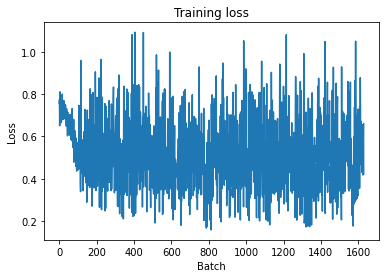

In [ ]:
optimizer = AdamW(model.parameters(), lr=1e-5)
NUM_EPOCHS = 20



scheduler = get_linear_schedule_with_warmup(optimizer, 
                                            num_warmup_steps=len(train_dataloader), 
                                            num_training_steps=len(train_dataloader)*NUM_EPOCHS)

train(model=model,
      optimizer=optimizer,
      scheduler=scheduler,
      train_dataloader=train_dataloader,
      validation_dataloader=validation_dataloader,
      num_epochs=NUM_EPOCHS)